# MAGIC Gamma Telescope EDA — Support Vector Machines

**Dataset:** UCI MAGIC Gamma Telescope (Bock et al., 2004)  
**Source:** Major Atmospheric Gamma Imaging Cherenkov Telescope  
**Samples:** 19,020 | **Features:** 10 continuous | **Target:** Binary (gamma signal vs hadron background)  
**Task:** Classify cosmic ray observations as gamma rays (signal) or hadrons (background noise)

## Purpose
Inspect raw data before any preprocessing touches it:
- Verify distributions, detect outliers and anomalies
- Quantify class imbalance (~65% gamma / ~35% hadron)
- Assess feature scales (critical for SVM — kernel distances depend on magnitude)
- Correlation analysis and feature-target relationships
- Every finding maps to a specific preprocessing decision

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import urllib.request
import os

# Configuration
RAW_DIR = Path('../data/raw')
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data'
RAW_PATH = RAW_DIR / 'magic04.data'

# Column names from UCI documentation (no header in file)
FEATURE_NAMES = [
    'fLength',   # Major axis of ellipse [mm]
    'fWidth',    # Minor axis of ellipse [mm]
    'fSize',     # 10-log of sum of content of all pixels [in #phot]
    'fConc',     # Ratio of sum of two highest pixels over fSize [ratio]
    'fConc1',    # Ratio of highest pixel over fSize [ratio]
    'fAsym',     # Distance from highest pixel to center, projected onto major axis [mm]
    'fM3Long',   # 3rd root of third moment along major axis [mm]
    'fM3Trans',  # 3rd root of third moment along minor axis [mm]
    'fAlpha',    # Angle of major axis with vector to origin [deg]
    'fDist'      # Distance from origin to center of ellipse [mm]
]
TARGET_NAME = 'class'

# Download if not present
if not RAW_PATH.exists():
    print("Downloading MAGIC Gamma Telescope dataset from UCI...")
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, RAW_PATH)
    print(f"    Saved to: {RAW_PATH}")
else:
    print(f"Dataset already exists: {RAW_PATH}")

# Load raw data
print("=" * 60)
print("LOADING RAW DATA")
print("=" * 60)
column_names = FEATURE_NAMES + [TARGET_NAME]
df = pd.read_csv(RAW_PATH, header=None, names=column_names)
print(f"\nShape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\n{df.head()}")
print(f"\n{df.describe()}")

    Saved to: ..\data\raw\magic04.data
LOADING RAW DATA

Shape: (19020, 11)
Columns (11): ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

Data types:
fLength     float64
fWidth      float64
fSize       float64
fConc       float64
fConc1      float64
fAsym       float64
fM3Long     float64
fM3Trans    float64
fAlpha      float64
fDist       float64
class        object
dtype: object

    fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580  -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   21.8393   

    fAlpha     fDist class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     

In [2]:
# Step 1: Missing values and duplicates
print("=" * 60)
print("[1/9] MISSING VALUES & DUPLICATES")
print("=" * 60)

# NaN check
print("\n--- NaN count per column ---")
missing = df.isnull().sum()
print(missing.to_string())
print(f"\nTotal NaN: {missing.sum()}")

# Duplicates
n_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {n_duplicates}")
if n_duplicates > 0:
    print(f"    {n_duplicates / len(df) * 100:.2f}% of dataset")
    print("    Action: Remove in preprocessing — duplicates inflate support vector counts")
else:
    print("    No duplicates found")

[1/9] MISSING VALUES & DUPLICATES

--- NaN count per column ---
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0

Total NaN: 0

Duplicate rows: 115
    0.60% of dataset
    Action: Remove in preprocessing — duplicates inflate support vector counts


[2/9] TARGET DISTRIBUTION

Target ('class') value counts:
  g (gamma (signal)): 12,332 (64.84%)
  h (hadron (background)):  6,688 (35.16%)

Imbalance ratio: 1.84 : 1


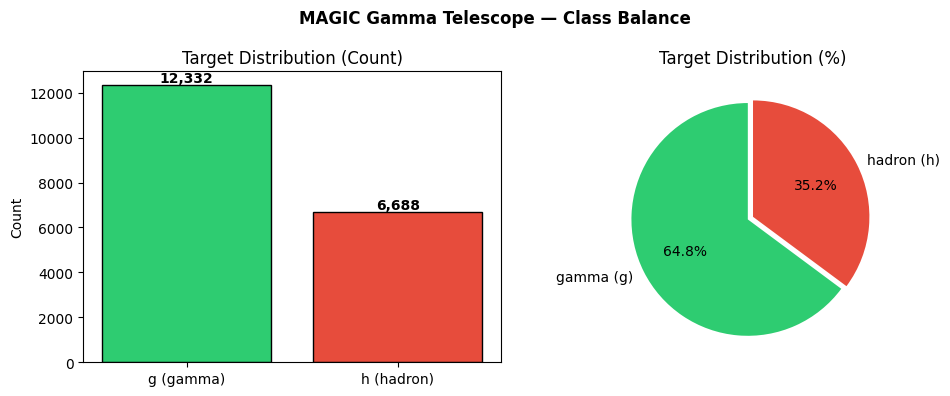


Saved: eda_svm_target_distribution.png
Action: Use class_weight='balanced' — moderate imbalance, not extreme like Bank Marketing


In [3]:
# Step 2: Target distribution and class imbalance
print("=" * 60)
print("[2/9] TARGET DISTRIBUTION")
print("=" * 60)

target_counts = df[TARGET_NAME].value_counts()
target_pcts = df[TARGET_NAME].value_counts(normalize=True) * 100

print("\nTarget ('class') value counts:")
for val in target_counts.index:
    label = "gamma (signal)" if val == 'g' else "hadron (background)"
    print(f"  {val} ({label}): {target_counts[val]:6,} ({target_pcts[val]:.2f}%)")

print(f"\nImbalance ratio: {target_counts['g'] / target_counts['h']:.2f} : 1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#2ecc71', '#e74c3c']  # green=gamma(signal), red=hadron(background)
labels = [f'g (gamma)\n{target_counts["g"]:,}', f'h (hadron)\n{target_counts["h"]:,}']

# Bar chart
axes[0].bar(['g (gamma)', 'h (hadron)'], target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Distribution (Count)')
axes[0].set_ylabel('Count')
for i, count in enumerate(target_counts.values):
    axes[0].text(i, count + 150, f'{count:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['gamma (g)', 'hadron (h)'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0))
axes[1].set_title('Target Distribution (%)')

plt.suptitle('MAGIC Gamma Telescope — Class Balance', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/raw/eda_svm_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: eda_svm_target_distribution.png")
print("Action: Use class_weight='balanced' — moderate imbalance, not extreme like Bank Marketing")

[3/9] FEATURE DISTRIBUTIONS
All 10 features are continuous (float64)


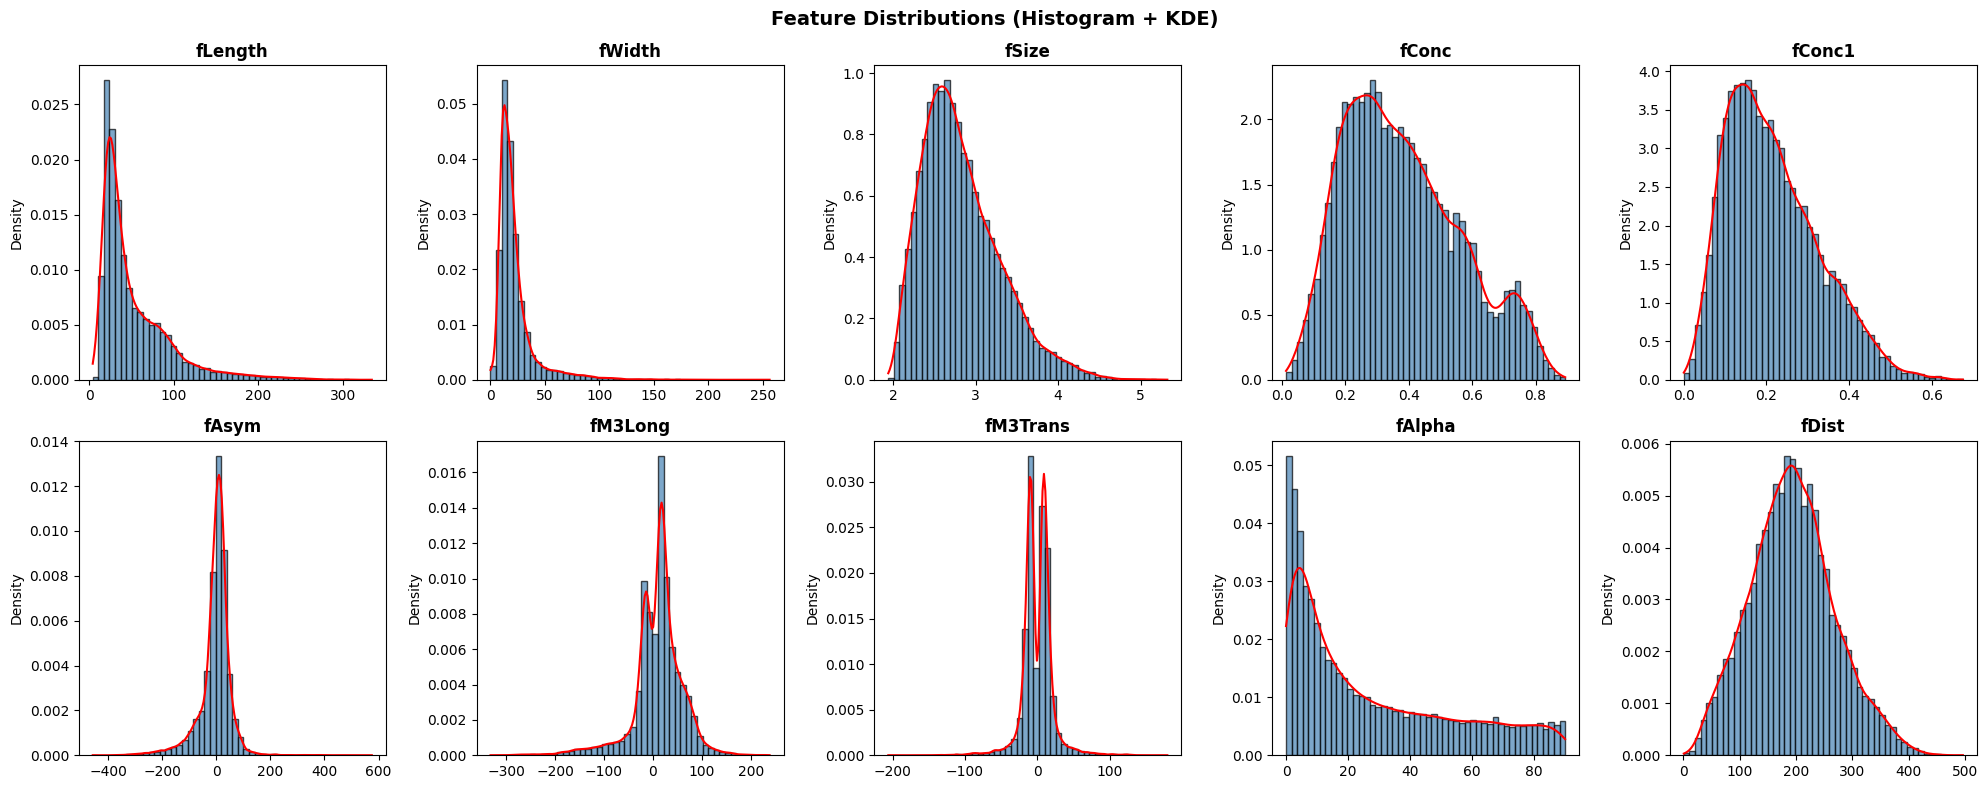


Saved: eda_svm_feature_distributions.png

Skewness:
  fLength   :   +2.014 ← highly skewed
  fWidth    :   +3.372 ← highly skewed
  fSize     :   +0.876
  fConc     :   +0.486
  fConc1    :   +0.686
  fAsym     :   -1.046
  fM3Long   :   -1.123
  fM3Trans  :   +0.120
  fAlpha    :   +0.851
  fDist     :   +0.230


In [4]:
# Step 3: Feature distributions (histograms + KDE)
print("=" * 60)
print("[3/9] FEATURE DISTRIBUTIONS")
print("=" * 60)

print(f"All {len(FEATURE_NAMES)} features are continuous (float64)")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
    
    # KDE overlay
    try:
        kde_x = np.linspace(df[col].min(), df[col].max(), 200)
        kde = stats.gaussian_kde(df[col])
        ax.plot(kde_x, kde(kde_x), color='red', linewidth=1.5)
    except Exception:
        pass
    
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions (Histogram + KDE)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/raw/eda_svm_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: eda_svm_feature_distributions.png")

# Skewness
print("\nSkewness:")
for col in FEATURE_NAMES:
    skew = df[col].skew()
    flag = " ← highly skewed" if abs(skew) > 2 else ""
    print(f"  {col:10s}: {skew:+8.3f}{flag}")

[4/9] OUTLIER DETECTION — BOX PLOTS + IQR


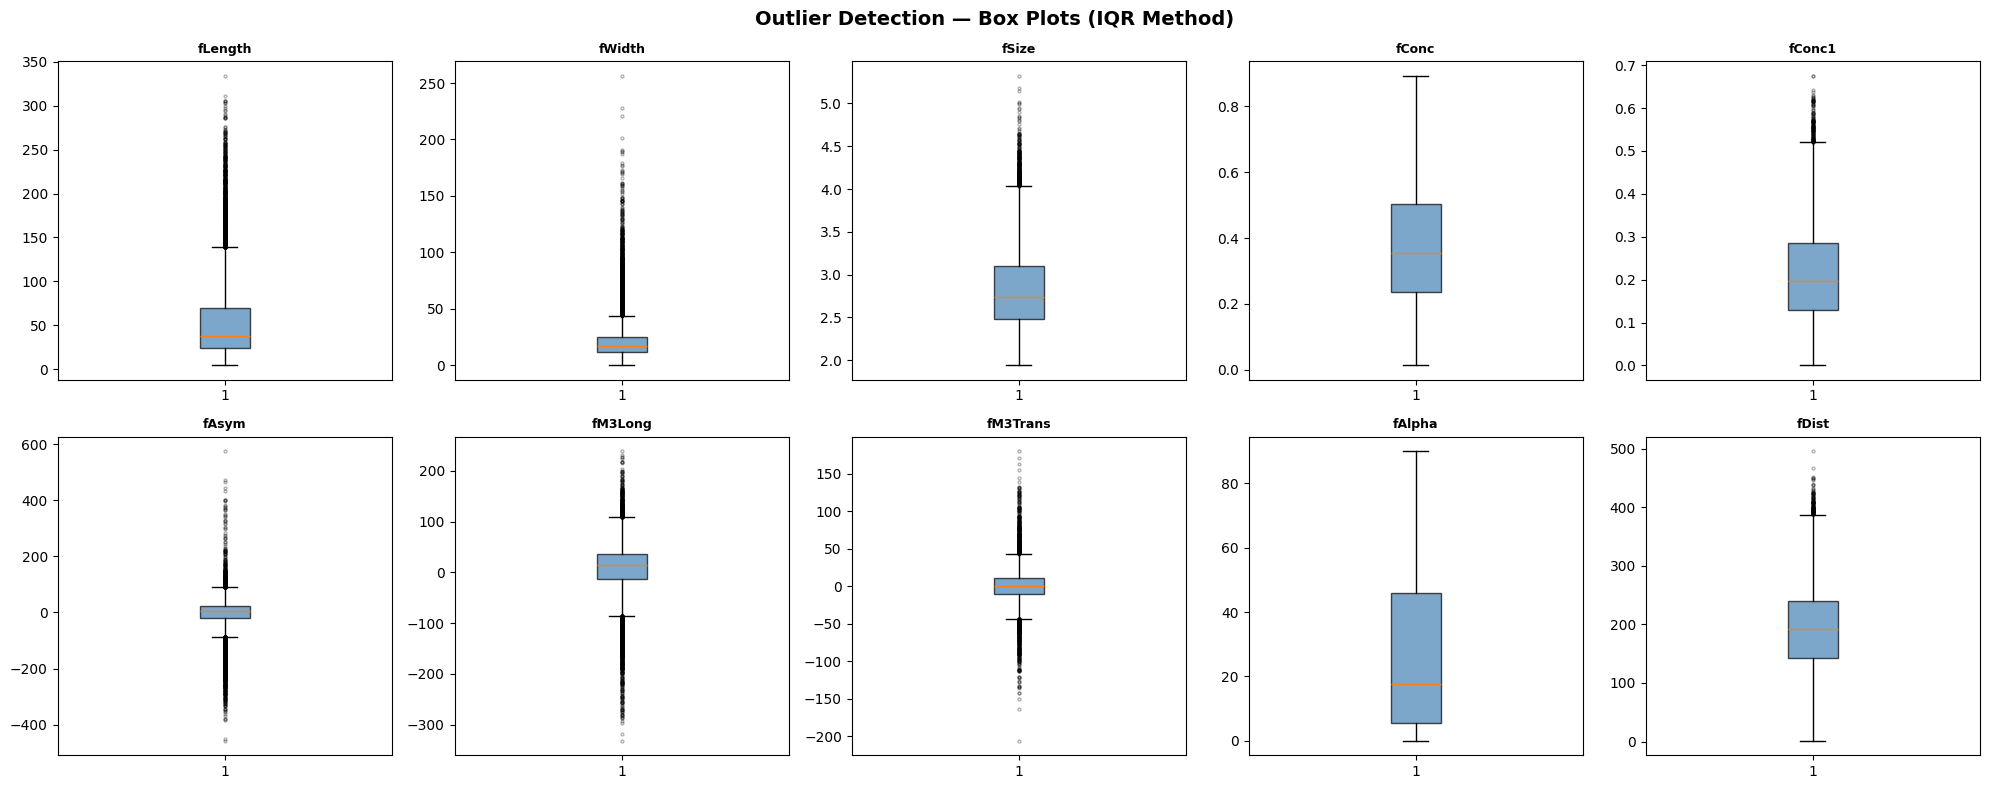


Saved: eda_svm_outlier_boxplots.png

Feature    Outliers       %       Lower       Upper
--------------------------------------------------
fLength         971   5.11%      -44.34      138.80
fWidth         1546   8.13%       -7.45       44.05
fSize           367   1.93%        1.54        4.04
fConc             0   0.00%       -0.17        0.91
fConc1          150   0.79%       -0.11        0.52
fAsym          1781   9.36%      -87.56       91.04
fM3Long        1218   6.40%      -85.86      108.86
fM3Trans        850   4.47%      -43.54       43.64
fAlpha            0   0.00%      -54.96      106.39
fDist           128   0.67%       -4.62      387.67

Decision: Keep all outliers — these are real physics measurements.
StandardScaler will normalize scales, and SVM with class_weight='balanced'
will handle margin placement. Extreme points may become support vectors.


In [5]:
# Step 4: Outlier detection (box plots + IQR)
# Important for SVM: outliers can become support vectors and shift the margin
print("=" * 60)
print("[4/9] OUTLIER DETECTION — BOX PLOTS + IQR")
print("=" * 60)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(FEATURE_NAMES):
    ax = axes[i]
    
    bp = ax.boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col, fontweight='bold', fontsize=9)
    
    # IQR calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n_outliers = len(outliers)
    pct = n_outliers / len(df) * 100
    outlier_summary[col] = {'count': n_outliers, 'pct': round(pct, 2),
                            'lower': round(lower, 2), 'upper': round(upper, 2)}

plt.suptitle('Outlier Detection — Box Plots (IQR Method)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/raw/eda_svm_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: eda_svm_outlier_boxplots.png")

print(f"\n{'Feature':10s} {'Outliers':>8s} {'%':>7s}  {'Lower':>10s}  {'Upper':>10s}")
print("-" * 50)
for col, info in outlier_summary.items():
    print(f"{col:10s} {info['count']:8d} {info['pct']:6.2f}%  {info['lower']:10.2f}  {info['upper']:10.2f}")

print("\nDecision: Keep all outliers — these are real physics measurements.")
print("StandardScaler will normalize scales, and SVM with class_weight='balanced'")
print("will handle margin placement. Extreme points may become support vectors.")

[5/9] FEATURE SCALE COMPARISON

Feature           Min        Max      Range       Mean        Std
------------------------------------------------------------
fLength         4.284    334.177    329.894     53.250     42.365
fWidth          0.000    256.382    256.382     22.181     18.346
fSize           1.941      5.323      3.382      2.825      0.473
fConc           0.013      0.893      0.880      0.380      0.183
fConc1          0.000      0.675      0.675      0.215      0.111
fAsym        -457.916    575.241   1033.157     -4.332     59.206
fM3Long      -331.780    238.321    570.101     10.546     51.000
fM3Trans     -205.895    179.851    385.746      0.250     20.827
fAlpha          0.000     90.000     90.000     27.646     26.104
fDist           1.283    495.561    494.278    193.818     74.732


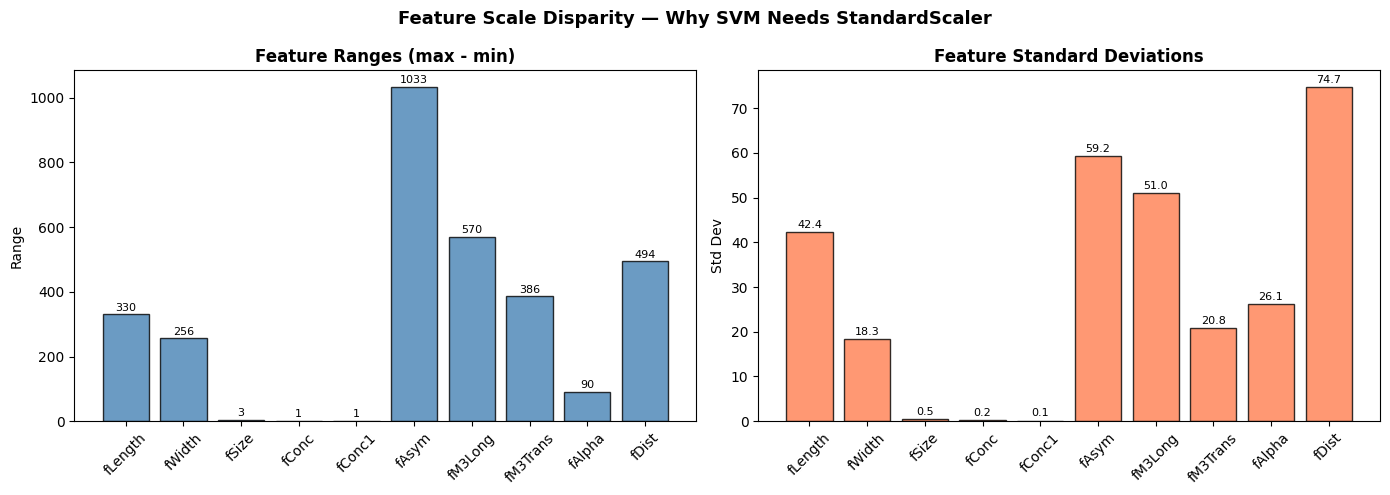


Saved: eda_svm_scale_comparison.png

Scale disparity:
  Range ratio (max/min): 1531x
  Std ratio (max/min):   676x

Action: StandardScaler required — fit on train, transform both


In [6]:
# Step 5: Feature scale comparison
# CRITICAL for SVM: kernel distances depend on feature magnitudes
# Without scaling, fDist (range ~495) dominates fConc1 (range ~0.67)
print("=" * 60)
print("[5/9] FEATURE SCALE COMPARISON")
print("=" * 60)

# Compare ranges, means, and standard deviations
print(f"\n{'Feature':10s} {'Min':>10s} {'Max':>10s} {'Range':>10s} {'Mean':>10s} {'Std':>10s}")
print("-" * 60)
for col in FEATURE_NAMES:
    col_min = df[col].min()
    col_max = df[col].max()
    col_range = col_max - col_min
    col_mean = df[col].mean()
    col_std = df[col].std()
    print(f"{col:10s} {col_min:10.3f} {col_max:10.3f} {col_range:10.3f} {col_mean:10.3f} {col_std:10.3f}")

# Visual: bar chart of feature ranges (shows scale disparity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ranges = [df[col].max() - df[col].min() for col in FEATURE_NAMES]
stds = [df[col].std() for col in FEATURE_NAMES]

# Panel 1: Feature ranges
bars = axes[0].bar(FEATURE_NAMES, ranges, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Feature Ranges (max - min)', fontweight='bold')
axes[0].set_ylabel('Range')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, ranges):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# Panel 2: Feature standard deviations
bars = axes[1].bar(FEATURE_NAMES, stds, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Feature Standard Deviations', fontweight='bold')
axes[1].set_ylabel('Std Dev')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, stds):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Feature Scale Disparity — Why SVM Needs StandardScaler', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/raw/eda_svm_scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: eda_svm_scale_comparison.png")

# Ratio of largest to smallest
max_range = max(ranges)
min_range = min(ranges)
max_std = max(stds)
min_std = min(stds)
print(f"\nScale disparity:")
print(f"  Range ratio (max/min): {max_range / min_range:.0f}x")
print(f"  Std ratio (max/min):   {max_std / min_std:.0f}x")
print(f"\nAction: StandardScaler required — fit on train, transform both")

[6/9] CORRELATION HEATMAP


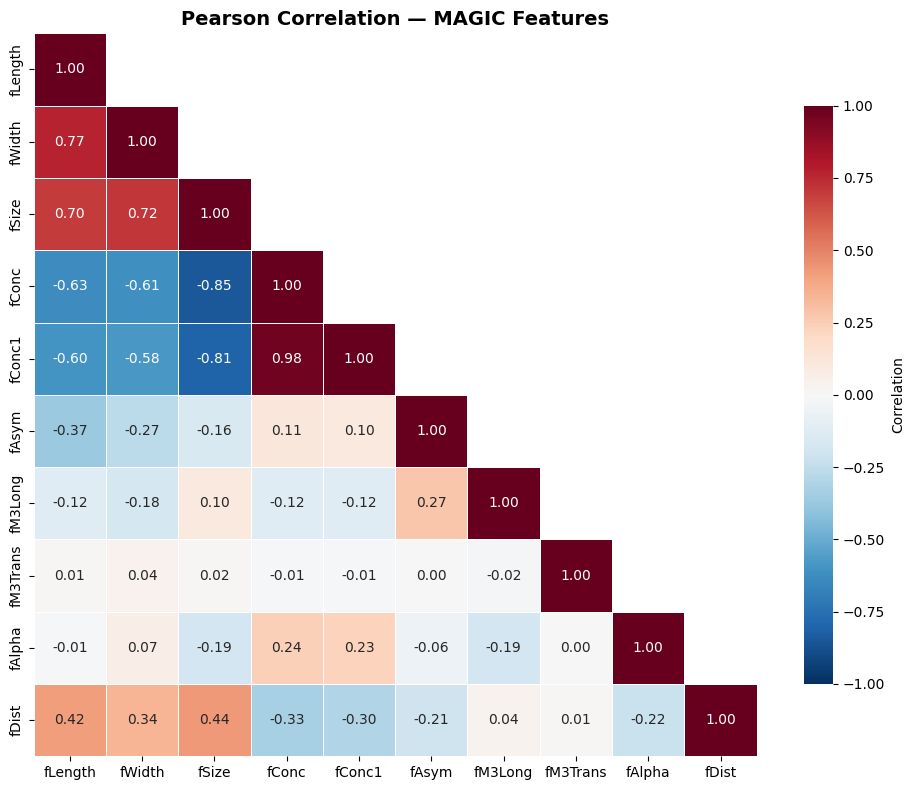


Saved: eda_svm_correlation_heatmap.png

Strongly correlated pairs (|r| > 0.7):
--------------------------------------------------
  fLength    <-> fWidth    : r = 0.771
  fLength    <-> fSize     : r = 0.702
  fWidth     <-> fSize     : r = 0.718
  fSize      <-> fConc     : r = -0.851
  fSize      <-> fConc1    : r = -0.809
  fConc      <-> fConc1    : r = 0.976

Note: SVM with RBF kernel handles correlated features naturally —
the kernel maps to high-dimensional space where correlations are less
impactful. No feature removal needed.


In [7]:
# Step 6: Correlation heatmap
print("=" * 60)
print("[6/9] CORRELATION HEATMAP")
print("=" * 60)

corr_matrix = df[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)
ax.set_title('Pearson Correlation — MAGIC Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/raw/eda_svm_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: eda_svm_correlation_heatmap.png")

# Strongly correlated pairs (|r| > 0.7)
print("\nStrongly correlated pairs (|r| > 0.7):")
print("-" * 50)
pairs_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            pairs_found = True
            print(f"  {corr_matrix.columns[i]:10s} <-> {corr_matrix.columns[j]:10s}: r = {r:.3f}")

if not pairs_found:
    print("  None found")

print("\nNote: SVM with RBF kernel handles correlated features naturally —")
print("the kernel maps to high-dimensional space where correlations are less")
print("impactful. No feature removal needed.")

[7/9] FEATURE-TARGET RELATIONSHIPS


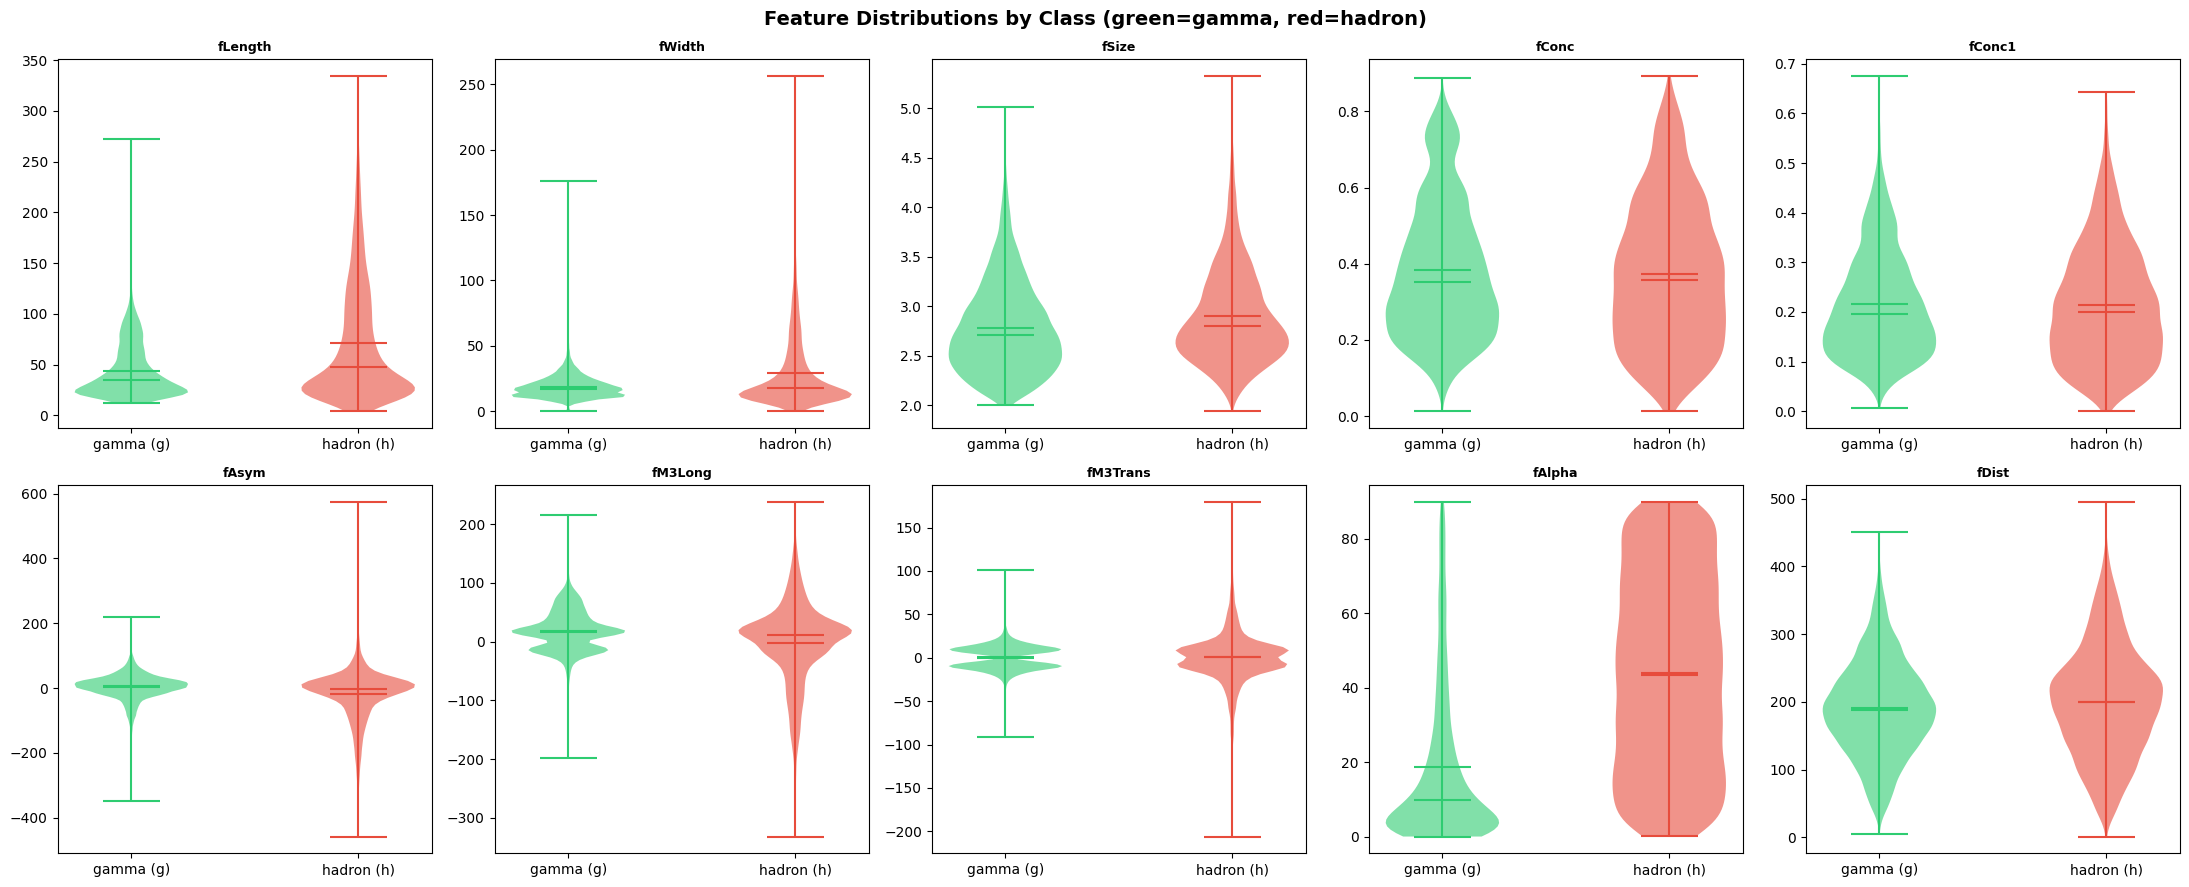


Saved: eda_svm_features_vs_target.png

Feature        Mean (g)     Mean (h)     Diff %
------------------------------------------------
fLength          43.655       70.944     -38.5%
fWidth           18.593       28.797     -35.4%
fSize             2.784        2.901      -4.0%
fConc             0.384        0.374      +2.5%
fConc1            0.215        0.214      +0.5%
fAsym             3.237      -18.287    +117.7%
fM3Long          17.809       -2.848    +725.3%
fM3Trans          0.191        0.358     -46.7%
fAlpha           18.784       43.985     -57.3%
fDist           190.230      200.435      -5.1%

Features with large class separation = strong discriminators for SVM


In [8]:
# Step 7: Feature-target relationships
# How each feature distributes across gamma vs hadron classes
print("=" * 60)
print("[7/9] FEATURE-TARGET RELATIONSHIPS")
print("=" * 60)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(FEATURE_NAMES):
    ax = axes[i]
    
    for label, color, pos in [('g', '#2ecc71', 0), ('h', '#e74c3c', 1)]:
        data = df[df[TARGET_NAME] == label][col]
        parts = ax.violinplot(data, positions=[pos], showmeans=True, showmedians=True)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
        for key in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
            parts[key].set_color(color)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['gamma (g)', 'hadron (h)'])
    ax.set_title(col, fontweight='bold', fontsize=9)

plt.suptitle('Feature Distributions by Class (green=gamma, red=hadron)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/raw/eda_svm_features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: eda_svm_features_vs_target.png")

# Mean differences between classes
print(f"\n{'Feature':10s} {'Mean (g)':>12s} {'Mean (h)':>12s} {'Diff %':>10s}")
print("-" * 48)
for col in FEATURE_NAMES:
    mean_g = df[df[TARGET_NAME] == 'g'][col].mean()
    mean_h = df[df[TARGET_NAME] == 'h'][col].mean()
    if mean_h != 0:
        diff_pct = (mean_g - mean_h) / abs(mean_h) * 100
    else:
        diff_pct = float('inf')
    print(f"{col:10s} {mean_g:12.3f} {mean_h:12.3f} {diff_pct:+9.1f}%")

print("\nFeatures with large class separation = strong discriminators for SVM")

In [9]:
# Step 8: Normality tests
# SVM doesn't assume normality, but documenting for comparison with other models
print("=" * 60)
print("[8/9] NORMALITY TESTS — D'AGOSTINO-PEARSON")
print("=" * 60)

print("\nNull hypothesis: data comes from a normal distribution")
print("Reject H0 if p-value < 0.05 (NOT normally distributed)")
print("Note: SVM makes no distributional assumptions — this is")
print("for documentation and comparison with other models.\n")

print(f"{'Feature':10s} {'Statistic':>12s} {'p-value':>14s}  {'Normal?':>10s} {'Skewness':>10s}")
print("-" * 62)
for col in FEATURE_NAMES:
    stat, p_value = stats.normaltest(df[col])
    skew = df[col].skew()
    normal = "Yes" if p_value >= 0.05 else "No"
    p_str = f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.4f}"
    print(f"{col:10s} {stat:12.1f} {p_str:>14s}  {normal:>10s} {skew:>+10.3f}")

print("\nResult: All features reject normality.")
print("Not a concern for SVM — kernel methods work on distances, not distributions.")

[8/9] NORMALITY TESTS — D'AGOSTINO-PEARSON

Null hypothesis: data comes from a normal distribution
Reject H0 if p-value < 0.05 (NOT normally distributed)
Note: SVM makes no distributional assumptions — this is
for documentation and comparison with other models.

Feature       Statistic        p-value     Normal?   Skewness
--------------------------------------------------------------
fLength          7732.5       0.00e+00          No     +2.014
fWidth          13855.2       0.00e+00          No     +3.372
fSize            2068.0       0.00e+00          No     +0.876
fConc            1083.2      6.10e-236          No     +0.486
fConc1           1233.5      1.42e-268          No     +0.686
fAsym            5342.9       0.00e+00          No     -1.046
fM3Long          4650.9       0.00e+00          No     -1.123
fM3Trans         3072.0       0.00e+00          No     +0.120
fAlpha           2192.0       0.00e+00          No     +0.851
fDist             174.2       1.52e-38          No    

## EDA Summary — Preprocessing Recommendations

### Findings → Actions

| # | Finding | Evidence | Action |
|---|---------|----------|--------|
| 1 | **No missing values** | 0 NaN across all 11 columns | No imputation needed |
| 2 | **115 duplicate rows** (0.6%) | `df.duplicated().sum() = 115` | **Drop in preprocessing** — prevents inflated support vector counts |
| 3 | **Class imbalance** (64.8% gamma / 35.2% hadron) | Target distribution, 1.84:1 ratio | `class_weight='balanced'` — moderate, no resampling needed |
| 4 | **Heavy right skew** in fLength (+2.0), fWidth (+3.4) | Histogram + skewness values | **No transform** — StandardScaler normalizes, RBF kernel handles non-normal data |
| 5 | **Outliers in most features** (0.7–9.4%) | IQR method, fAsym highest at 9.4% | **Keep all** — real physics measurements, may become informative support vectors |
| 6 | **Massive scale disparity** (1531x range, 676x std) | fAsym range 1033 vs fConc1 range 0.67 | **StandardScaler required** — fit on train only, transform both |
| 7 | **Strong correlations** (fConc↔fConc1: r=0.98) | Correlation heatmap, 6 pairs above 0.7 | **No feature removal** — RBF kernel handles correlated features in high-dim space |
| 8 | **Good class separation** on several features | Violin plots + mean differences | fAlpha (-57%), fM3Long (+725%), fAsym (+118%), fLength/fWidth (-35–38%) are strong discriminators |
| 9 | **All features non-normal** | D'Agostino p ≈ 0 for all 10 features | **No concern** — SVM makes no distributional assumptions |
| 10 | **All features continuous** (float64) | dtypes check | No categorical encoding needed |

### Preprocessing Pipeline (→ `preprocess_svm.py`)
1. Download MAGIC dataset (if not present)
2. Load raw CSV (19,020 × 11, no header)
3. Check and remove duplicates (115 rows)
4. Encode target: g → 1, h → 0
5. Stratified 80/20 split (`random_state=113`)
6. StandardScaler — fit on train ONLY, transform both (no data leakage)
7. Save: X_train, X_test, y_train, y_test + preprocessing_info.json

**Final feature count:** 10 (all continuous, all kept)